In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import sklearn

In [2]:
df=pd.read_excel('/home/yazid/sklearn/customer-segmentation/data/customer_segmentation.xlsx')

In [3]:
len(df)

541909

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Let's start by preparing the df for K-means(Clustering algorithm):

In [8]:
#We get rid of unkown customers:
df.dropna(inplace=True)

In [9]:
#We have illogical values we could get rid of :
df['Quantity'].min()

-80995

In [10]:
df=df[df['Quantity']>0]

In [11]:
df=df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [12]:
df['TotalSpend']=df['Quantity']*df['UnitPrice']

In [13]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [14]:
#We create reference date:
reference_date=df['InvoiceDate'].max()+pd.Timedelta(1)

In [15]:
customer=df.groupby('CustomerID').agg({'InvoiceDate':lambda x:(reference_date-x.max()).days,
                                      'InvoiceNo':'nunique',
                                      'TotalSpend':'sum'}).reset_index()

In [16]:
customer.rename(columns={'InvoiceDate':'Recency','InvoiceNo':'Frequency','TotalSpend':'Monetary'},inplace=True)

Now we start working on the final df that we will pass to k-means:

In [17]:
customer.columns.to_list()

['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [18]:
customer.describe()

,CustomerID,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,91.518322,4.271952,2053.793018
std,1721.889758,100.009747,7.705493,8988.248381
min,12346.000000,0.000000,1.000000,0.000000
25%,13812.500000,17.000000,1.000000,307.245000
50%,15299.000000,50.000000,2.000000,674.450000
75%,16778.500000,141.000000,5.000000,1661.640000
max,18287.000000,373.000000,210.000000,280206.020000


In [19]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4339 non-null   float64
 1   Recency     4339 non-null   int64  
 2   Frequency   4339 non-null   int64  
 3   Monetary    4339 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.7 KB


In [22]:
from sklearn.preprocessing import StandardScaler
features=['Recency','Frequency','Monetary']
X=customer[features]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

We will use the elbow method to determine how many clusters we are going to use :

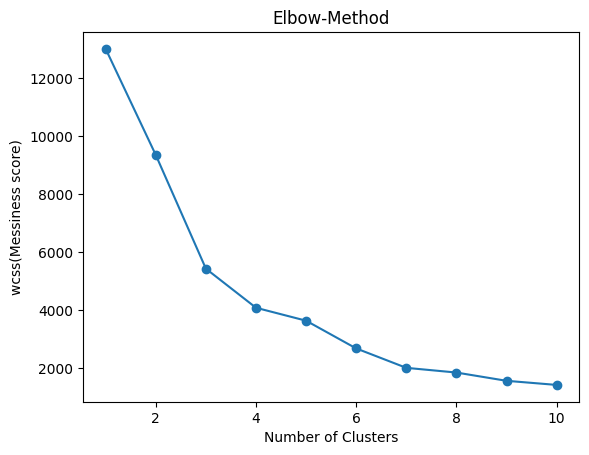

In [29]:
from sklearn.cluster import KMeans
#wcss->within cluster sum of squares: higher score->distant customer low_score->rightly profiled
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss,marker='o')
plt.title('Elbow-Method')
plt.xlabel('Number of Clusters')
plt.ylabel('wcss(Messiness score)')
plt.show()